In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o /home/dnanexus/data_dir/

olink_whitelist = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o /home/dnanexus/data_dir/

olink_corrs = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_correlations_file}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_reg
ression_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False
extreme_pheno_dir = 'bottom'
# abs_phenotypes = True

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""regulatory""","""fz_all_mean""","""#FFA500""","""Flashzoi mean across RNA all""",1
"""regulatory_nondir""","""promoterai_abs""","""#80CBC4""","""PromoterAI abs""",-1
"""regulatory_nondir""","""abexp_abs_max""","""#b5de2b""","""AbExp abs max""",-1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Core promoter
        (pl.col('promoterai_is_na') == False),
        
        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),
        # ((pl.col('consequence_intron_variant') == True) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),
        # (pl.col('consequence_synonymous_variant') == True),
        # (pl.col('consequence_5_prime_utr_variant') == True),
        # (pl.col('consequence_upstream_gene_variant') == True),
        # (pl.col('consequence_downstream_gene_variant') == True),
        # (pl.col('consequence_intron_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        # (pl.col('not_in_encode') == False),
        # (pl.col('encode_eh_pr') == True),
        # (pl.col('encode_all_tf') == True),

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range),
        # (pl.col('dist_to_tss') <= max_range),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_52126/1355264871.py:88: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_52126/1355264871.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


absplice_dna_max,promoterai_abs,gpn_score,region,promoterai,delta_score,abexp_min,verphylop,pangolin_score,cadd_raw,absplice2_max,id,abexp_abs_max
f32,f32,f32,str,f32,f32,f32,f32,f32,f32,f32,str,f32
0.001,0.0215,-7.45,"""ENSG00000155657""",-0.0215,0.0,-0.015385,2.713,0.0,2.389754,0.000033,"""chr2:178795028:T:C""",0.015385
0.001,0.0011,-1.37,"""ENSG00000198431""",0.0011,0.0,-0.006438,-0.263,0.0,0.317683,0.000033,"""chr12:104285872:C:G""",0.006438
0.001,0.0027,-1.82,"""ENSG00000049249""",-0.0027,0.0,-0.006063,0.37,0.0,0.353388,0.000033,"""chr1:7934802:T:G""",0.006063
0.003,0.0028,0.24,"""ENSG00000124256""",0.0028,0.01,-0.011448,-2.303,0.01,-1.004218,0.000275,"""chr20:57610501:G:C""",0.171446
0.003,0.05,-5.43,"""ENSG00000156234""",0.05,0.04,-0.069889,3.794,0.04,3.889862,0.000348,"""chr4:77605888:T:C""",0.069889
…,…,…,…,…,…,…,…,…,…,…,…,…
0.001,0.0536,-3.9,"""ENSG00000124145""",-0.0536,0.0,-0.014604,0.557,0.0,1.621368,0.000033,"""chr20:45348183:A:G""",0.014604
0.001,0.0636,-1.13,"""ENSG00000100380""",-0.0636,0.0,-0.006438,-0.042,0.0,0.619822,0.000033,"""chr22:40856166:C:T""",0.006438
0.004,0.0046,0.0,"""ENSG00000091129""",0.0046,0.08,-0.026591,0.102,0.07,0.365143,0.000374,"""chr7:108243063:T:C""",0.026591


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_52126/3727860496.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:70248972:G:C""","""ENSG00000116001""","""abexp_abs_max""",1
"""chr19:44699156:T:A""","""ENSG00000213892""","""abexp_abs_max""",1
"""chr17:36018358:A:C""","""ENSG00000274736""","""abexp_abs_max""",1
"""chr19:44699164:G:A""","""ENSG00000213892""","""abexp_abs_max""",1
"""chr9:97047170:G:A""","""ENSG00000136943""","""abexp_abs_max""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_52126/315562140.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr11:7673661:G:A""","""ENSG00000166394""","""absplice_dna_max""",0.006,"""splicing""",1,32110.0
"""chr16:57640244:A:G""","""ENSG00000205336""","""absplice_dna_max""",0.003,"""splicing""",1,227487.0
"""chr10:32957325:T:C""","""ENSG00000150093""","""absplice_dna_max""",0.003,"""splicing""",1,227487.0
"""chr3:51983227:G:T""","""ENSG00000114779""","""absplice_dna_max""",0.001,"""splicing""",1,426302.0
"""chr19:40281270:C:A""","""ENSG00000105221""","""absplice_dna_max""",0.001,"""splicing""",1,426302.0
…,…,…,…,…,…,…
"""chr1:207053180:C:T""","""ENSG00000123836""","""absplice_dna_max""",0.004,"""splicing""",1,65315.0
"""chr6:46170874:C:T""","""ENSG00000112796""","""absplice_dna_max""",0.003,"""splicing""",1,227487.0
"""chr17:4895921:G:A""","""ENSG00000141503""","""absplice_dna_max""",0.003,"""splicing""",1,227487.0


In [8]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",674458
"""gpn_score""",674458
"""promoterai""",674458
"""abexp_min""",674458
"""promoterai_abs""",674458
…,…
"""abexp_abs_max""",668638
"""absplice2_max""",507695
"""pangolin_score""",507617


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
            .then(pl.col('mean_pheno_value').abs())
            .otherwise(pl.col('mean_pheno_value')),
        # mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
        #     .then(1 - pl.col('mean_pheno_value_ptile'))
        #     .otherwise(pl.col('mean_pheno_value_ptile')),
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(pl.col('mean_pheno_value_ptile'))
            .otherwise(1 - pl.col('mean_pheno_value_ptile'))
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [10]:
olink_appv.head().collect()

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,mean_pheno_value_rank,mean_pheno_value_ptile
str,str,i32,f32,f32,f32,f32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",1,0.328067,null,1.720632e6,0.36397
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",1,-1.312343,null,4.311464e6,0.933468
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",1,0.249114,null,2.082593e6,0.392066
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1,1.00197,null,705046.0,0.133705
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",1,-0.059154,null,2.813642e6,0.530968


## Odds ratio computation

In [11]:
n_steps = 101
min_rank_cutoff = 1_0
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

rank_cutoff
f32
10.0
11.0
12.0
13.0
15.0
…
448937.0
501933.0
561185.0


In [12]:
id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE
gp_base = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(1 - pl.col('mean_pheno_value_ptile'))
                .otherwise(pl.col('mean_pheno_value_ptile'))
            >= or_threshold_pheno
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

print(f"gp_base: {gp_base.shape}, extreme: {gp_base['is_extreme'].sum()}")

# Process one annotation at a time — peak RAM is ~1 annotation's worth
results = []
for annotation in tqdm(melted_anno['annotation'].unique().sort()):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by('annotation_score_dircor_rank_desc')
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort('annotation_score_dircor_rank_desc')
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum(),
            cum_total = pl.col('n_total').cum_sum(),
        )
    )

    total_extreme = rank_counts['n_extreme'].sum()
    total_count = rank_counts['n_total'].sum()

    result = (
        cutoffs_sorted
        .join_asof(
            rank_counts,
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .with_columns(
            annotation = pl.lit(annotation),
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.lit(total_extreme) - pl.col('cum_extreme'),
            n_notdis_below = pl.lit(total_count - total_extreme)
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .select(['annotation', 'rank_cutoff', 'n_dis_above', 'n_notdis_above',
                 'n_dis_below', 'n_notdis_below'])
    )
    results.append(result)

# Combine and compute OR + Woolf CI
or_df = (
    pl.concat(results)
    .with_columns(
        odds_ratio = (pl.col('n_dis_above') / pl.col('n_notdis_above'))
                   / (pl.col('n_dis_below') / pl.col('n_notdis_below'))
    )
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .with_columns(
        se_log_or = (
            1/pl.col('n_dis_above').cast(pl.Float64)
            + 1/pl.col('n_notdis_above').cast(pl.Float64)
            + 1/pl.col('n_dis_below').cast(pl.Float64)
            + 1/pl.col('n_notdis_below').cast(pl.Float64)
        ).sqrt(),
    )
    .with_columns(
        ci_lower = (pl.col('odds_ratio').cast(pl.Float64).log() - 1.96 * pl.col('se_log_or')).exp(),
        ci_upper = (pl.col('odds_ratio').cast(pl.Float64).log() + 1.96 * pl.col('se_log_or')).exp(),
    )
    .sort('rank_cutoff', descending=True)
)

or_df

gp_base: (147799, 3), extreme: 3709


100%|██████████| 11/11 [00:00<00:00, 23.61it/s]


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,f64,f64,f64,f64
"""abexp_abs_max""",627432.0,2547,134761,1138,8016,0.133131,0.037464,0.123706,0.143275
"""abexp_min""",627432.0,3593,133905,116,10185,2.355936,0.094893,1.956091,2.837513
"""cadd_raw""",627432.0,3599,133513,110,10577,2.591959,0.097318,2.141851,3.136656
"""gpn_score""",627432.0,3579,132894,130,11196,2.319401,0.089825,1.94498,2.765901
"""promoterai""",627432.0,3522,134149,187,9941,1.395695,0.07576,1.203101,1.619118
…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",11.0,2,2,3707,144088,38.869166,1.000138,5.473565,276.019757
"""promoterai""",11.0,3,1,3706,144089,116.639773,1.15482,12.129523,1121.630003
"""absplice2_max""",10.0,1,1,3137,108471,34.577941,1.41433,2.162208,552.968915


## Plotting

In [13]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove shaky data points
    .filter(
        (pl.col('n_dis_above')>5),
        (pl.col('n_dis_below')>5),
        (pl.col('n_notdis_above')>5),
        (pl.col('n_notdis_below')>5),
    )
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""absplice_dna_max""",66.0,6,7,2999,96175,27.487734,0.556658,9.232141,81.841849,1.819544,-1.819544,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",66.0,9,6,3700,144084,58.412432,0.527309,20.780244,164.195005,1.819544,-1.819544,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""absplice_dna_max""",74.0,6,7,2999,96175,27.487734,0.556658,9.232141,81.841849,1.869232,-1.869232,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",74.0,10,7,3699,144083,55.645541,0.493087,21.169303,146.269638,1.869232,-1.869232,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""promoterai""",74.0,8,7,3701,144083,44.492377,0.517817,16.125419,122.760938,1.869232,-1.869232,"""#00A99D""","""PromoterAI""","""regulatory"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cadd_raw""",627432.0,3599,133513,110,10577,2.591959,0.097318,2.141851,3.136656,5.797567,-5.797567,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",627432.0,3579,132894,130,11196,2.319401,0.089825,1.94498,2.765901,5.797567,-5.797567,"""pink""","""GPN-MSA""","""conservation"""
"""promoterai""",627432.0,3522,134149,187,9941,1.395695,0.07576,1.203101,1.619118,5.797567,-5.797567,"""#00A99D""","""PromoterAI""","""regulatory"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


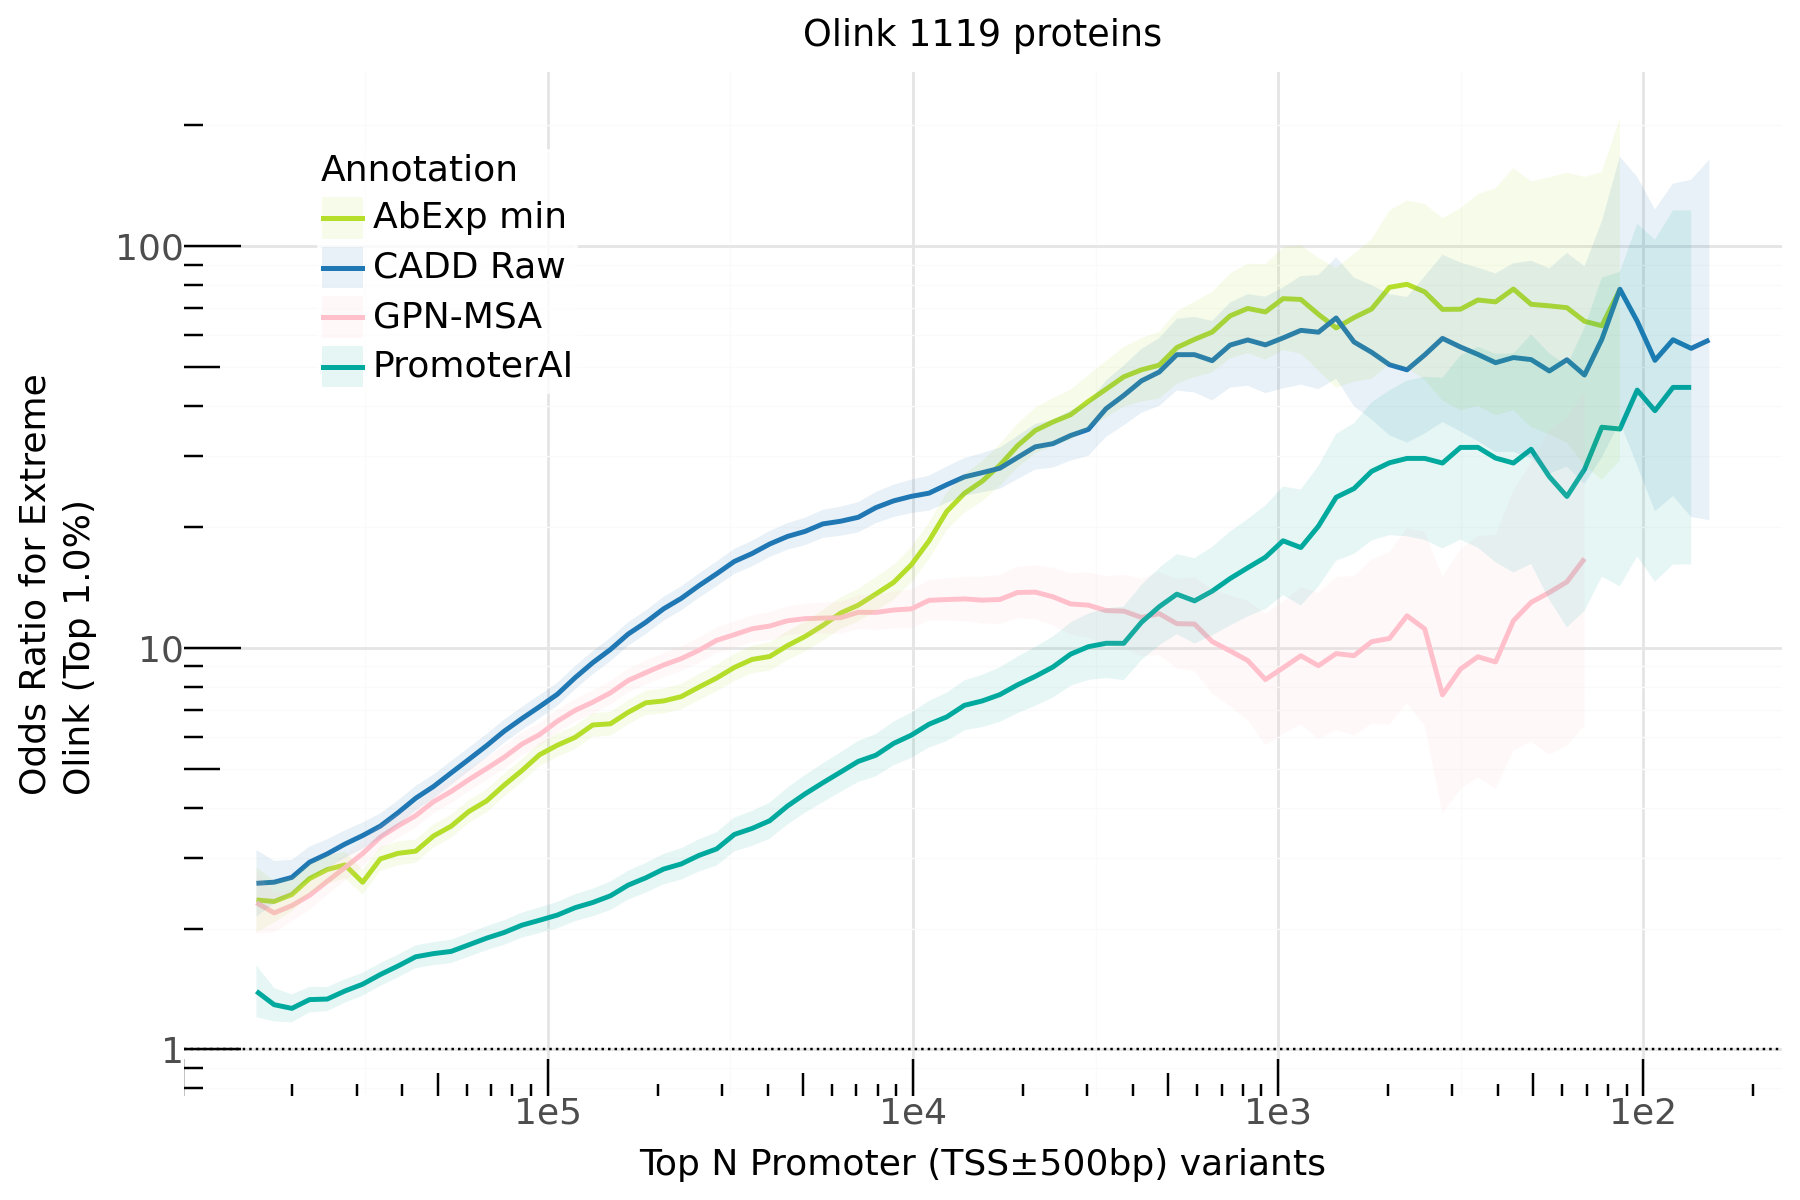

In [16]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score', 'absplice2_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'abexp_min', 'promoterai']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    # + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins",
        y=f"Odds Ratio for Extreme\nOlink (Top {pheno_label}%)",
        x=f"Top N Promoter (TSS±500bp) variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
plt_df.head()

annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""absplice_dna_max""",66.0,6,7,2999,96175,27.487734,0.556658,9.232141,81.841849,1.819544,-1.819544,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",66.0,9,6,3700,144084,58.412432,0.527309,20.780244,164.195005,1.819544,-1.819544,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""absplice_dna_max""",74.0,6,7,2999,96175,27.487734,0.556658,9.232141,81.841849,1.869232,-1.869232,"""#26C6DA""","""AbSplice (max)""","""splicing"""
"""cadd_raw""",74.0,10,7,3699,144083,55.645541,0.493087,21.169303,146.269638,1.869232,-1.869232,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""promoterai""",74.0,8,7,3701,144083,44.492377,0.517817,16.125419,122.760938,1.869232,-1.869232,"""#00A99D""","""PromoterAI""","""regulatory"""
